# v11 Summary — Write-Up Figure Set and Master Results

The index for the research write-up. Nothing is computed from scratch here: it assembles the master
results table and the curated figure set produced by the four analysis notebooks.

| notebook | what it establishes |
|---|---|
| `sharadar_results_v11.ipynb` | the model works in development — gates, books, alpha/beta |
| `comparing_models.ipynb` | Random Forest beats XGBoost and LightGBM, most decisively in the tail |
| `monte_carlo_v11.ipynb` | ruin risk, drawdown pain and how noisy a short measurement window is |
| `holdout_v11.ipynb` | **the single look** at 2023-2026 |

Reading order for the paper: development result → model choice → risk → holdout.

**Frozen configuration:** RF, **H=40 label**, **top 1%**, `monthly_tranche2` (~42-session hold), 80/20
hedge. Each of those was settled by experiment — see §9, §11 and §13 of `sharadar_results_v11`. The
60/40 hedge was dropped after the Monte Carlo showed it was indistinguishable from owning SPY.

⚠️ **The holdout was run on H=20**, before the label-horizon question was raised. So the holdout tests
an earlier configuration than the one now frozen, and H=40 has no out-of-sample test.

**Conventions throughout.** Sharpe and Sortino are excess of **Rf = 3.75%**. Strategy returns are net
of modelled transaction cost; SPY is buy-and-hold. All figures at 200 dpi in `report/figures/`.

In [1]:
import os
import sys as _sys

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
if os.getcwd() not in _sys.path:
    _sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
from IPython.display import Image, display, Markdown
import sh_analysis as an

DATA, FIGDIR = "data_sharadar", os.path.join("report", "figures")
RF_ANNUAL, RF_DAILY = 0.0375, 0.0375 / 252

SERIES = {"pure long": "monthly_tranche2",
          "80/20 hedge": "monthly_tranche2 80/20 hedge",
          "continuous": "continuous",
          "SPY": "SPY"}
# DEV and HOLDOUT both use the FROZEN configuration: H=40 label, top 1%, 500K training cap.
BOOKS = {
    ("DEV 2006-2022 · H=40", "top 1%"):      f"{DATA}/sh_books_h40_top1.parquet",
    ("HOLDOUT 2023-2026 · H=40", "top 1%"):  f"{DATA}/sh_books_holdout_h40_top1.parquet",
}


def daily_from(df, col):
    s = df[col].dropna()
    r = s.pct_change(fill_method=None)
    r.iloc[0] = s.iloc[0] - 1.0
    return r


rows = []
for (period, thr), path in BOOKS.items():
    eq = pd.read_parquet(path)
    eq.index = pd.to_datetime(eq.index)
    ex = an.metrics_table({c: daily_from(eq, c) for c in eq.columns},
                          target=RF_DAILY).set_index("book")
    for nice, col in SERIES.items():
        # SPY is buy-and-hold: identical under both thresholds, so record it ONCE per period with
        # threshold "—". Listing it twice implied the benchmark changed with the threshold.
        if nice == "SPY" and thr != "top 1%":
            continue
        s = eq[col].dropna()
        r = ex.loc[col]
        rows.append({"period": period, "threshold": "—" if nice == "SPY" else thr, "book": nice,
                     "CAGR": r.CAGR, "vol": r.vol, "Sharpe": r.Sharpe, "Sortino": r.Sortino,
                     "maxDD": r.maxDD, "Calmar": r.Calmar,
                     "Total Ret": s.iloc[-1] / s.iloc[0] - 1, "Final X": s.iloc[-1] / s.iloc[0]})

MASTER = pd.DataFrame(rows)
MASTER.to_csv("report/master_results.csv", index=False)
print(f"report/master_results.csv  ({len(MASTER)} rows)")

show = MASTER.set_index(["period", "threshold", "book"]).sort_index()
print(f"\nMASTER RESULTS · Sharpe/Sortino excess of {RF_ANNUAL:.2%} · strategies net of cost\n")
print(show.assign(CAGR=show.CAGR.map("{:+.1%}".format), vol=show.vol.map("{:.1%}".format),
                  Sharpe=show.Sharpe.round(2), Sortino=show.Sortino.round(2),
                  maxDD=show.maxDD.map("{:.1%}".format), Calmar=show.Calmar.round(2),
                  **{"Total Ret": show["Total Ret"].map("{:+.0%}".format),
                     "Final X": show["Final X"].map("{:.2f}x".format)}).to_string())

report/master_results.csv  (8 rows)

MASTER RESULTS · Sharpe/Sortino excess of 3.75% · strategies net of cost

                                                  CAGR    vol  Sharpe  Sortino   maxDD  Calmar Total Ret Final X
period                   threshold book                                                                         
DEV 2006-2022 · H=40     top 1%    80/20 hedge  +13.9%  23.1%    0.52     0.76  -50.3%    0.28     +792%   8.92x
                                   continuous   +13.6%  33.8%    0.44     0.63  -69.2%    0.20     +782%   8.82x
                                   pure long    +15.7%  33.6%    0.49     0.71  -62.7%    0.25    +1068%  11.68x
                         —         SPY           +8.8%  20.1%    0.34     0.47  -55.2%    0.16     +323%   4.23x
HOLDOUT 2023-2026 · H=40 top 1%    80/20 hedge  +20.5%  17.4%    0.95     1.39  -16.7%    1.22      +94%   1.94x
                                   continuous   +28.4%  29.8%    0.87     1.24  -26.1%    1.09    

---
## The five figures for the write-up

In this order. The first four carry the argument; the fifth is the methods figure.

**1. The decision dashboard.** Risk of ruin, drawdown, terminal wealth and median return across four horizons, with SPY run through identical machinery. If only one figure survives editing, use the top-left panel.

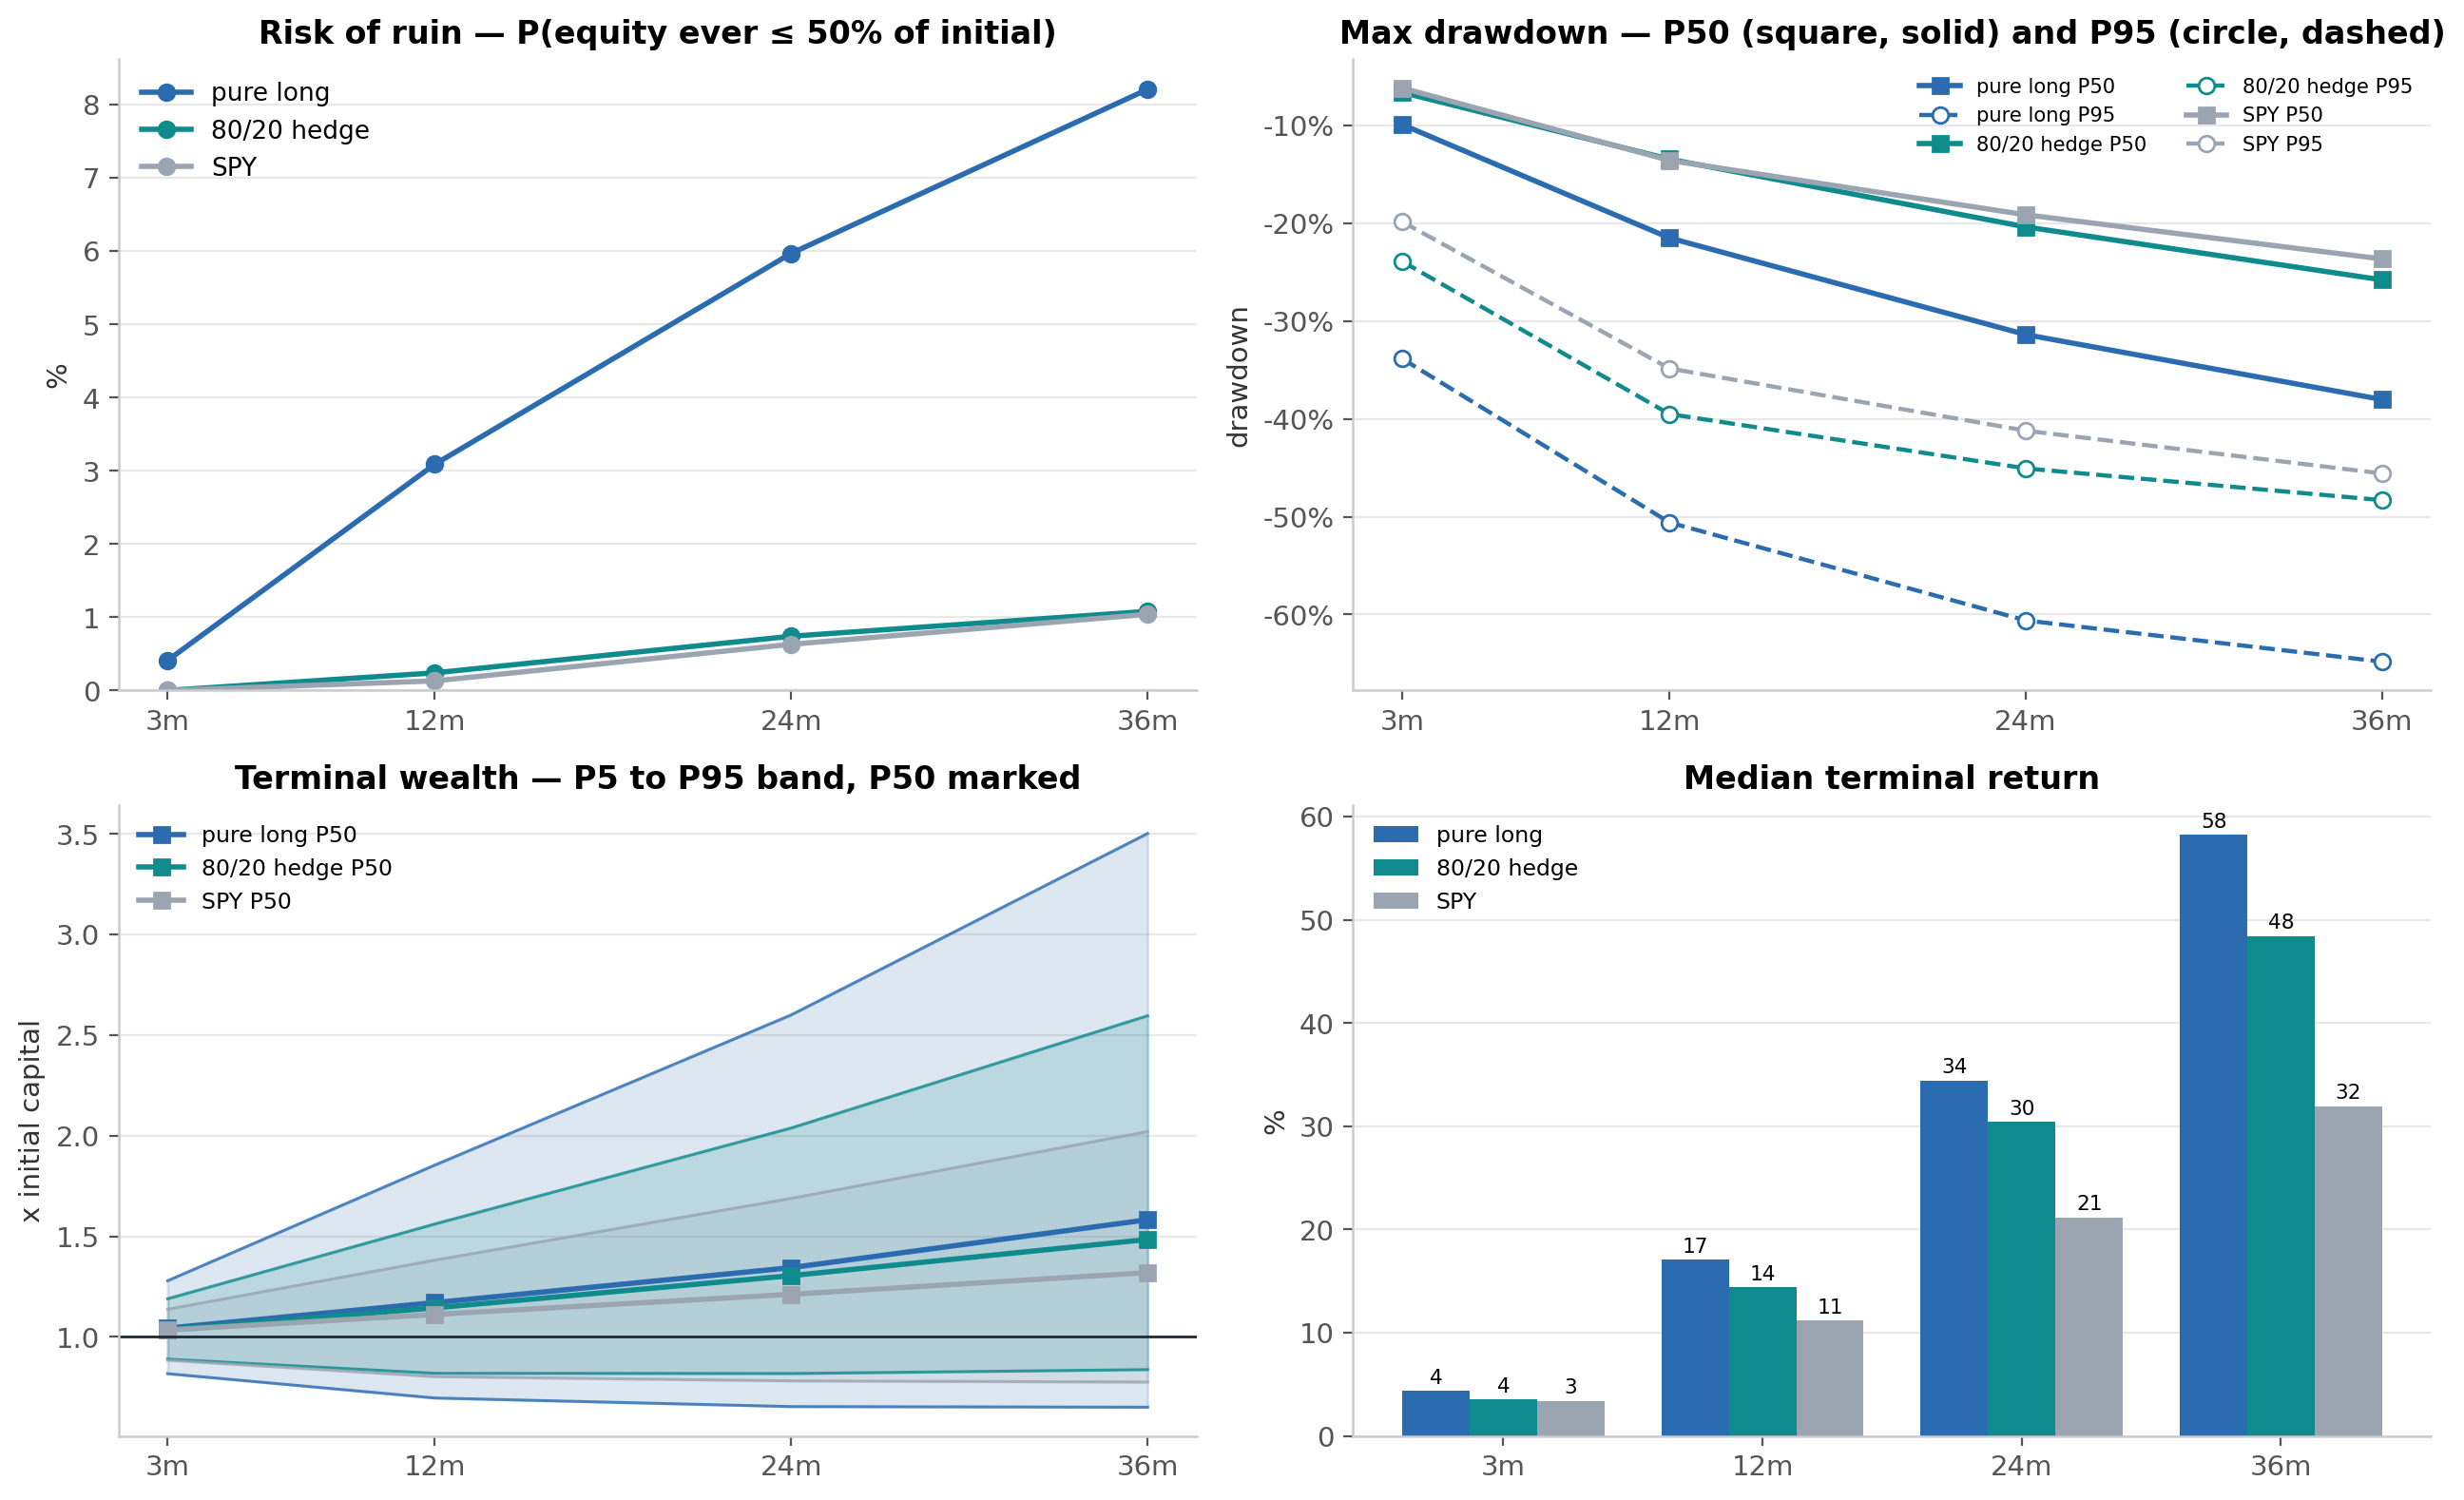

**2. Terminal wealth fans.** P10/P50/P90 through time. Pairs with #1 — that one gives the probability of a bad outcome, this one gives its magnitude. Note P10 sits below 1.0x at every horizon for every book.

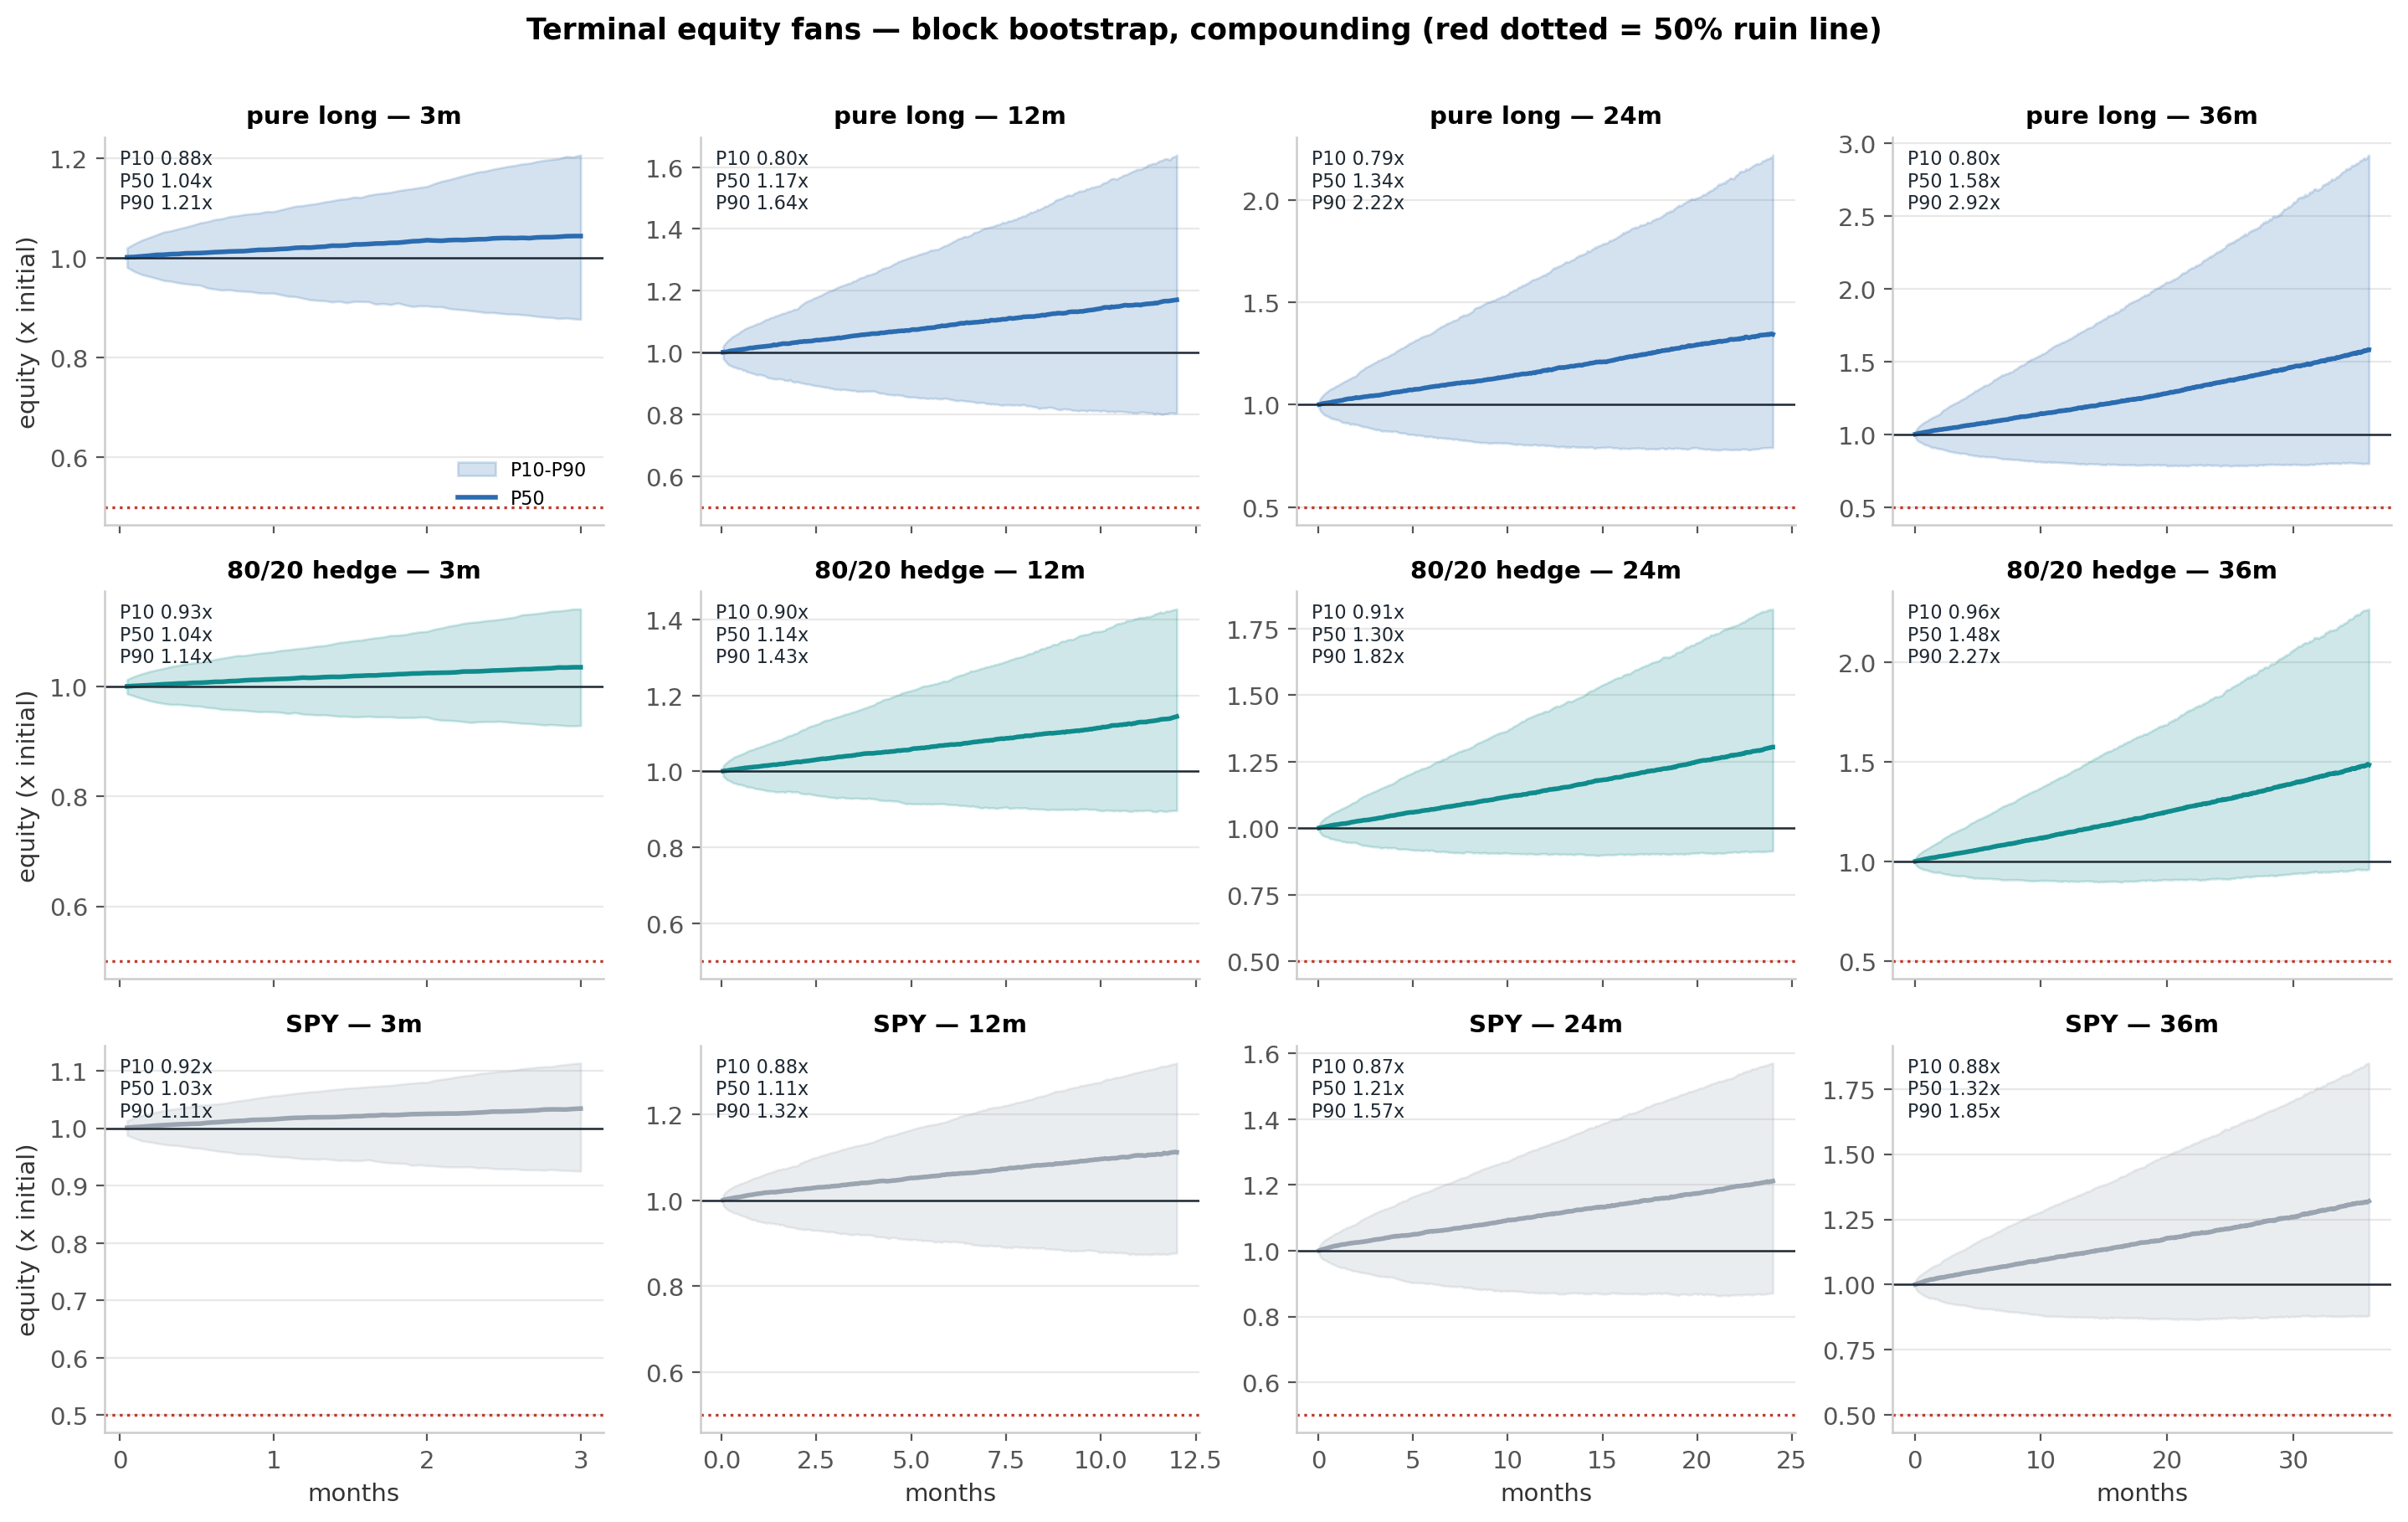

**3. Max drawdown distribution.** The shape matters more than the percentiles, which is why this is a histogram. Red dotted line is the 50% ruin threshold.

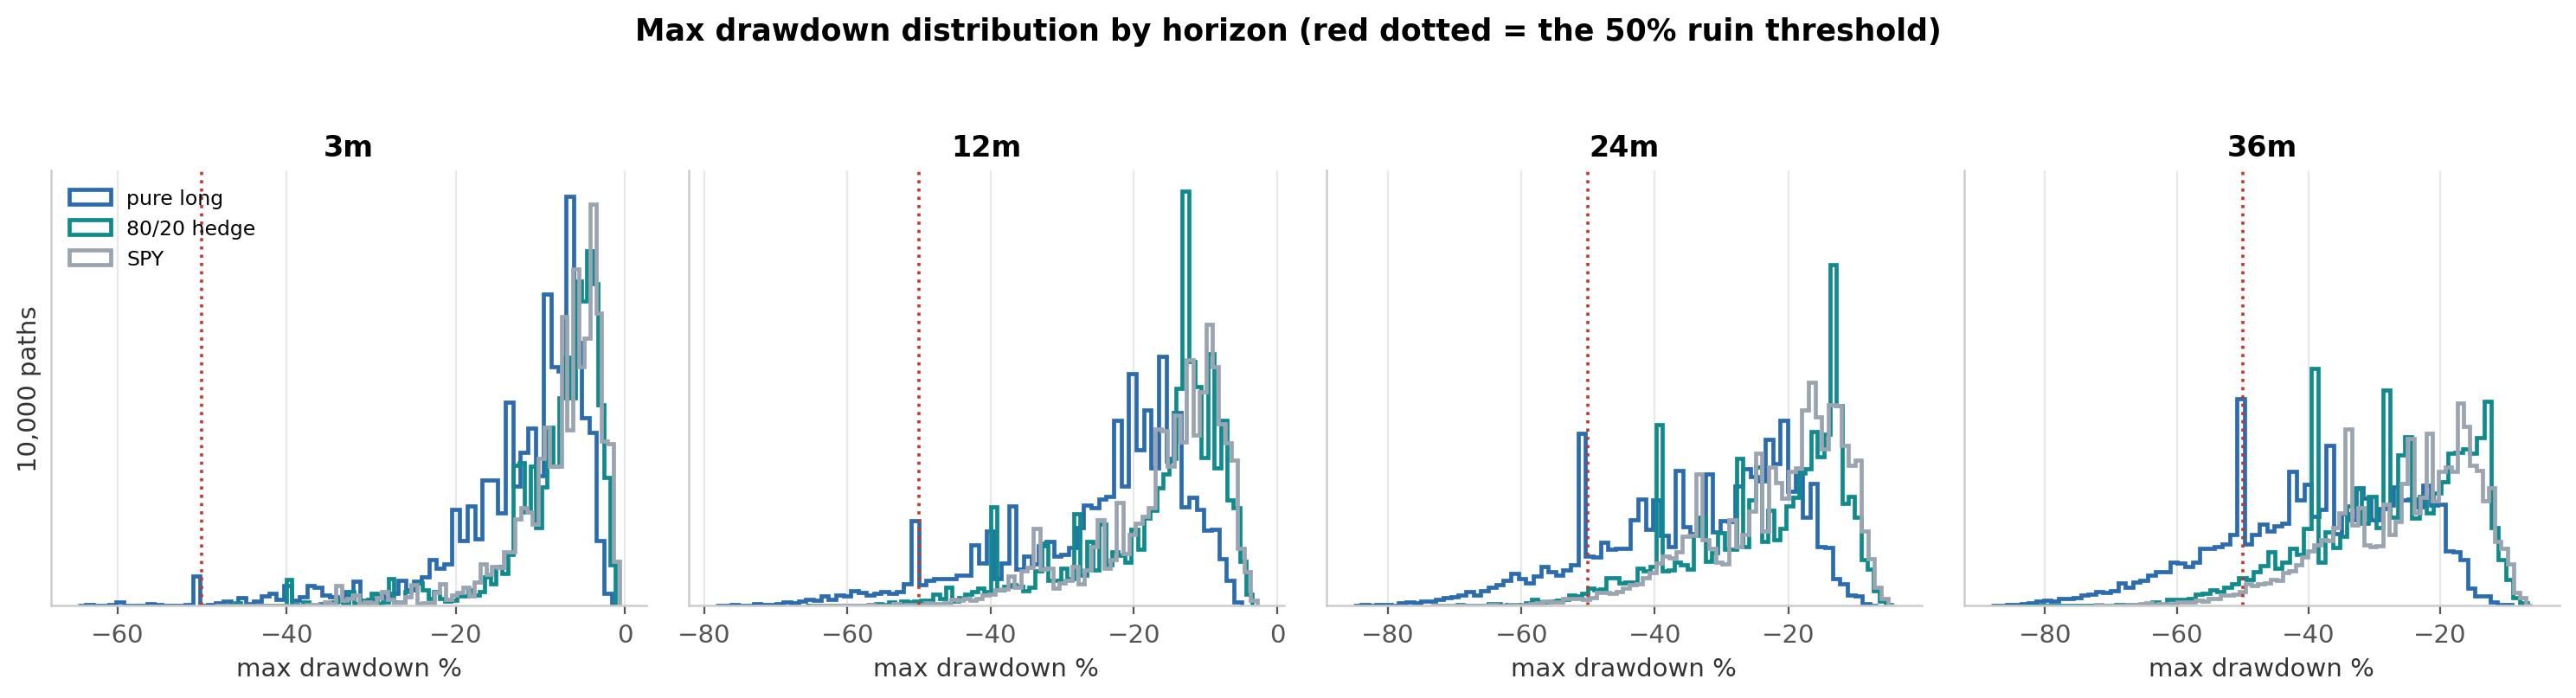

**4. The Sharpe funnel.** Same strategy in every path; only sequencing luck differs. Measured Sharpe over 3 months spans roughly ±3, narrowing to about [0, 0.8] at 36 months. The most useful figure here for anyone who has judged a strategy on one quarter.

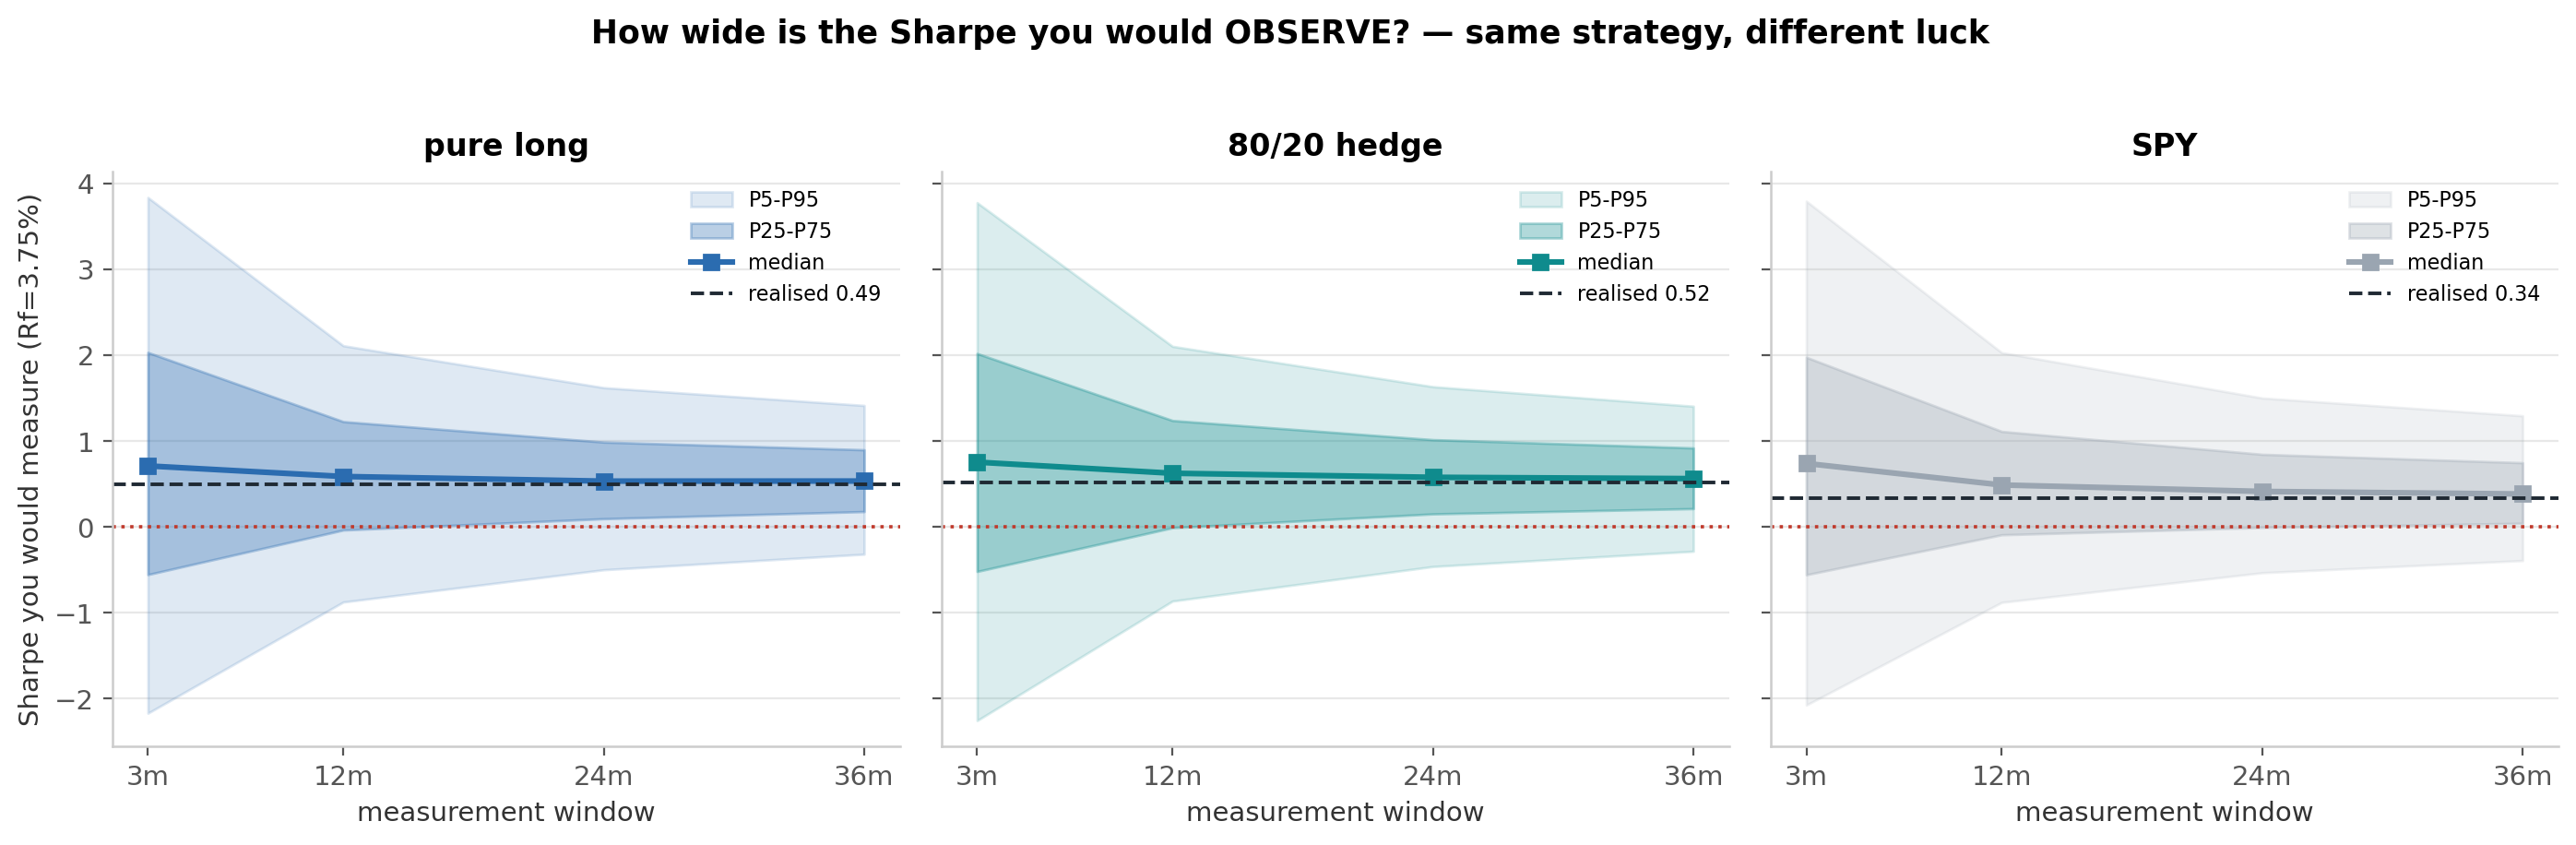

**5. Block bootstrap vs i.i.d.-normal (methods).** Proof the distributional assumption was tested rather than assumed. Ruin risk runs 1.9-5.0x higher under the realistic model at 12 months, converging by 36 as the central limit theorem takes over.

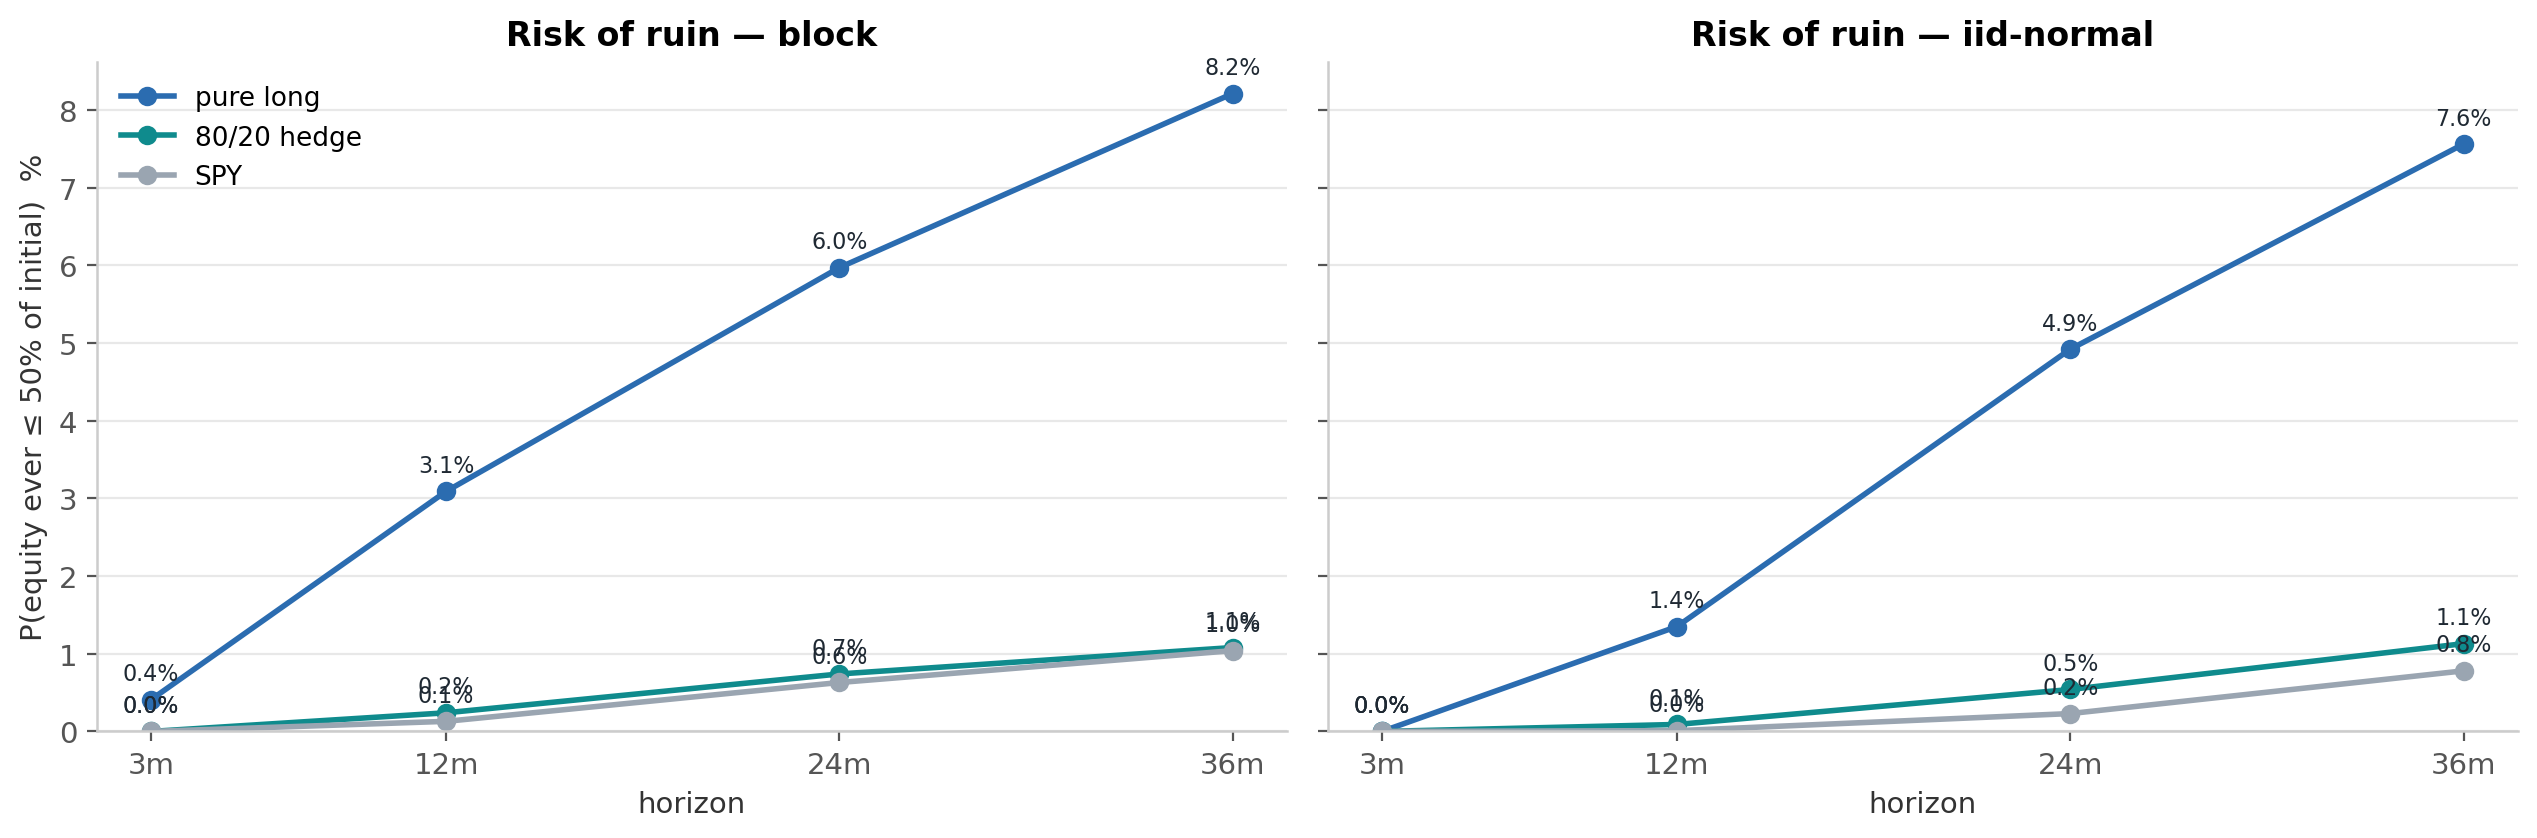

In [2]:
FIGS = [
    ("mc_01_dashboard",
     "**1. The decision dashboard.** Risk of ruin, drawdown, terminal wealth and median return "
     "across four horizons, with SPY run through identical machinery. If only one figure survives "
     "editing, use the top-left panel."),
    ("mc_05_equity_fans",
     "**2. Terminal wealth fans.** P10/P50/P90 through time. Pairs with #1 — that one gives the "
     "probability of a bad outcome, this one gives its magnitude. Note P10 sits below 1.0x at every "
     "horizon for every book."),
    ("mc_03_maxdd_distribution",
     "**3. Max drawdown distribution.** The shape matters more than the percentiles, which is why "
     "this is a histogram. Red dotted line is the 50% ruin threshold."),
    ("mc_06_sharpe_funnel",
     "**4. The Sharpe funnel.** Same strategy in every path; only sequencing luck differs. Measured "
     "Sharpe over 3 months spans roughly ±3, narrowing to about [0, 0.8] at 36 months. The most "
     "useful figure here for anyone who has judged a strategy on one quarter."),
    ("mc_02_ruin_block_vs_iid",
     "**5. Block bootstrap vs i.i.d.-normal (methods).** Proof the distributional assumption was "
     "tested rather than assumed. Ruin risk runs 1.9-5.0x higher under the realistic model at 12 "
     "months, converging by 36 as the central limit theorem takes over."),
]
for name, caption in FIGS:
    display(Markdown(caption))
    display(Image(filename=os.path.join(FIGDIR, f"{name}.png"), width=980))

### Supporting figures, if space allows

The holdout equity curve is the natural sixth. Beyond that, `results_03_decile_threshold` is the
cleanest single picture of the signal working, and `models_03_threshold_sweep` is the cleanest picture
of why Random Forest was kept.

**Holdout equity, H=40 top 1%.** The pure long book finished 3.02x against SPY's 2.06x, with excess Sharpe 1.16 against 1.15 — a dead heat risk-adjusted, a clear win on total return.

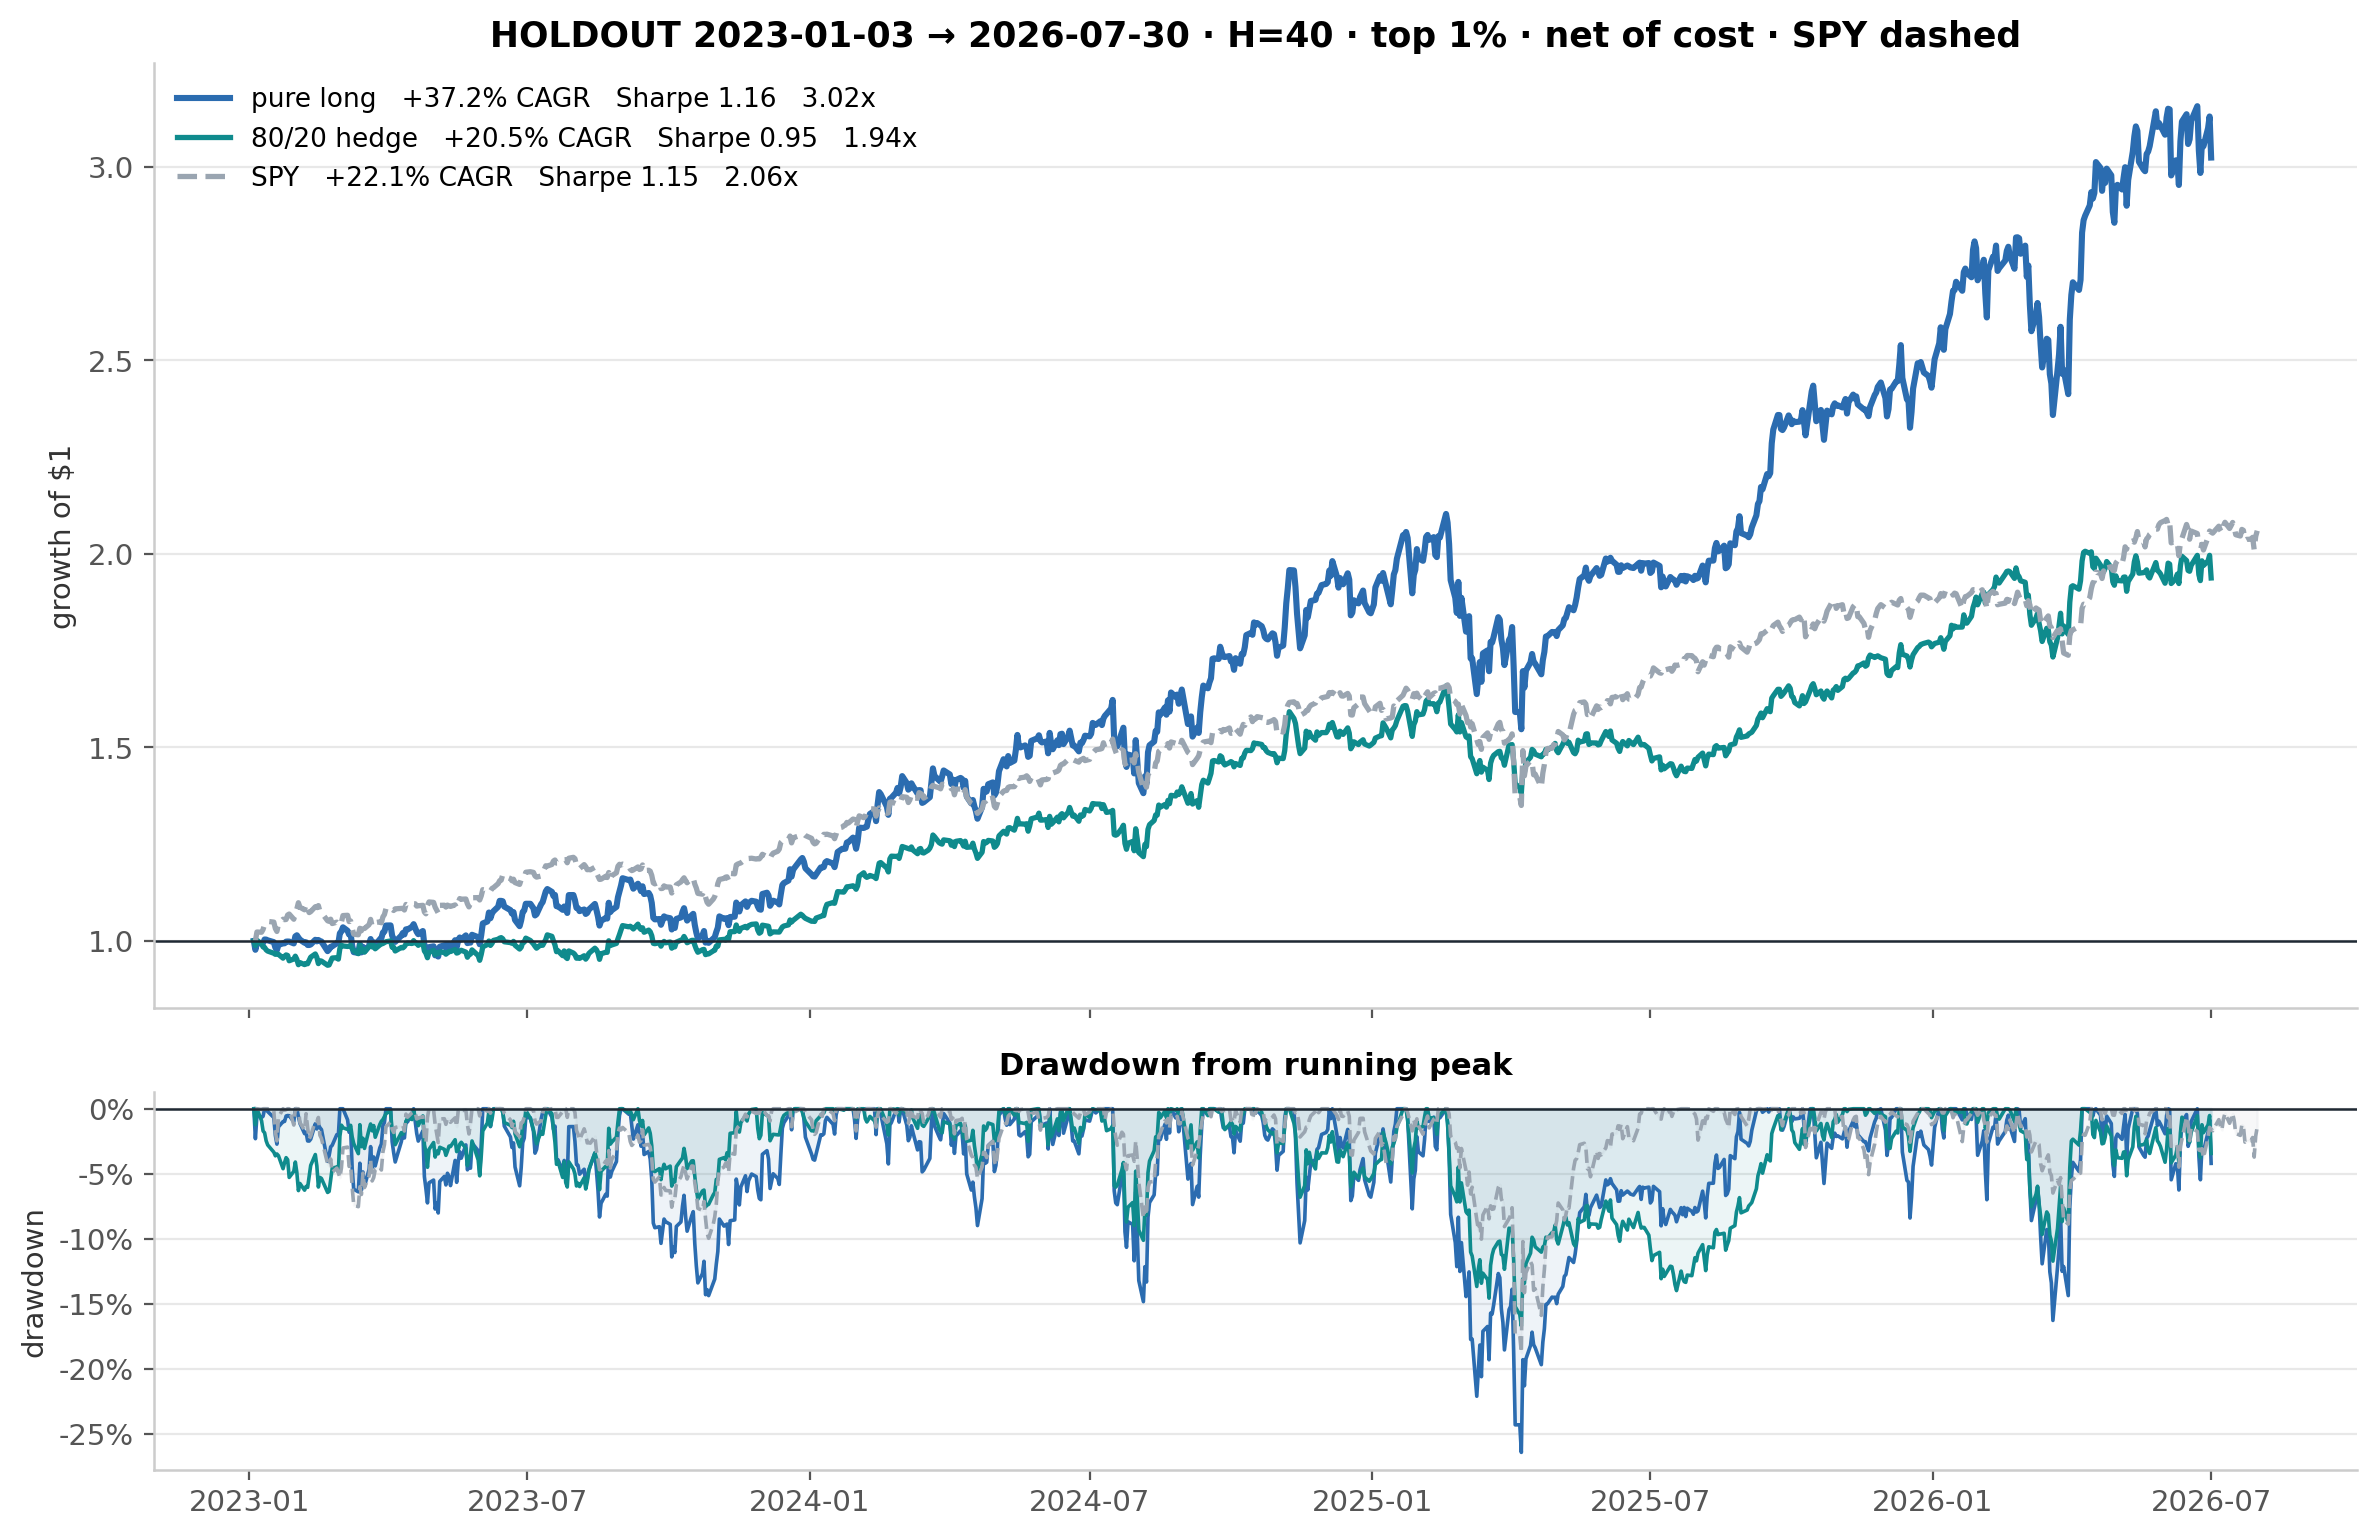

**Development: the signal works.** Monotone decile ladder from −0.60% to +2.35% per trade, and return per trade still rising at the top 1% where the book trades.

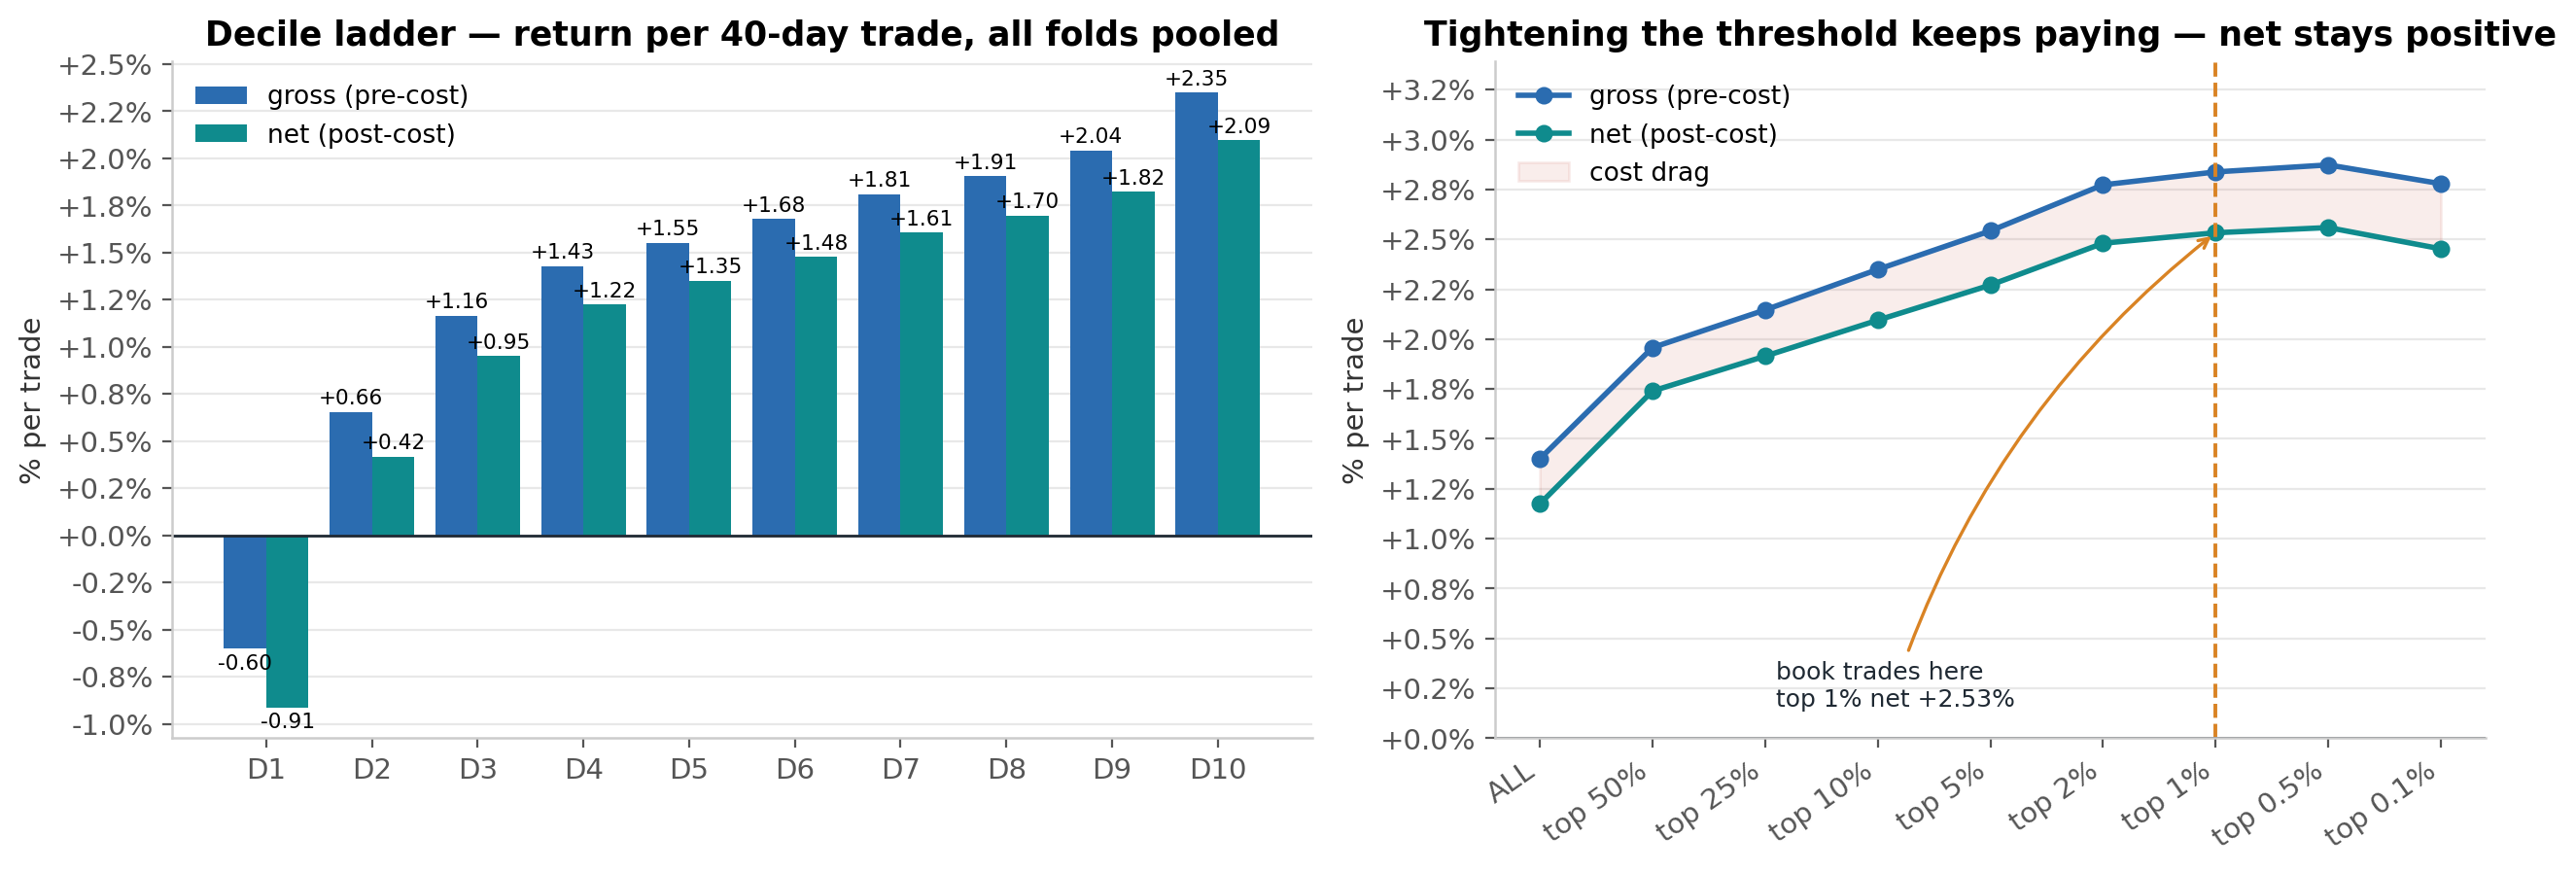

**Why Random Forest.** Both boosters roll over in the tail; RF keeps climbing as the threshold tightens, which is the only part of the ranking the book trades.

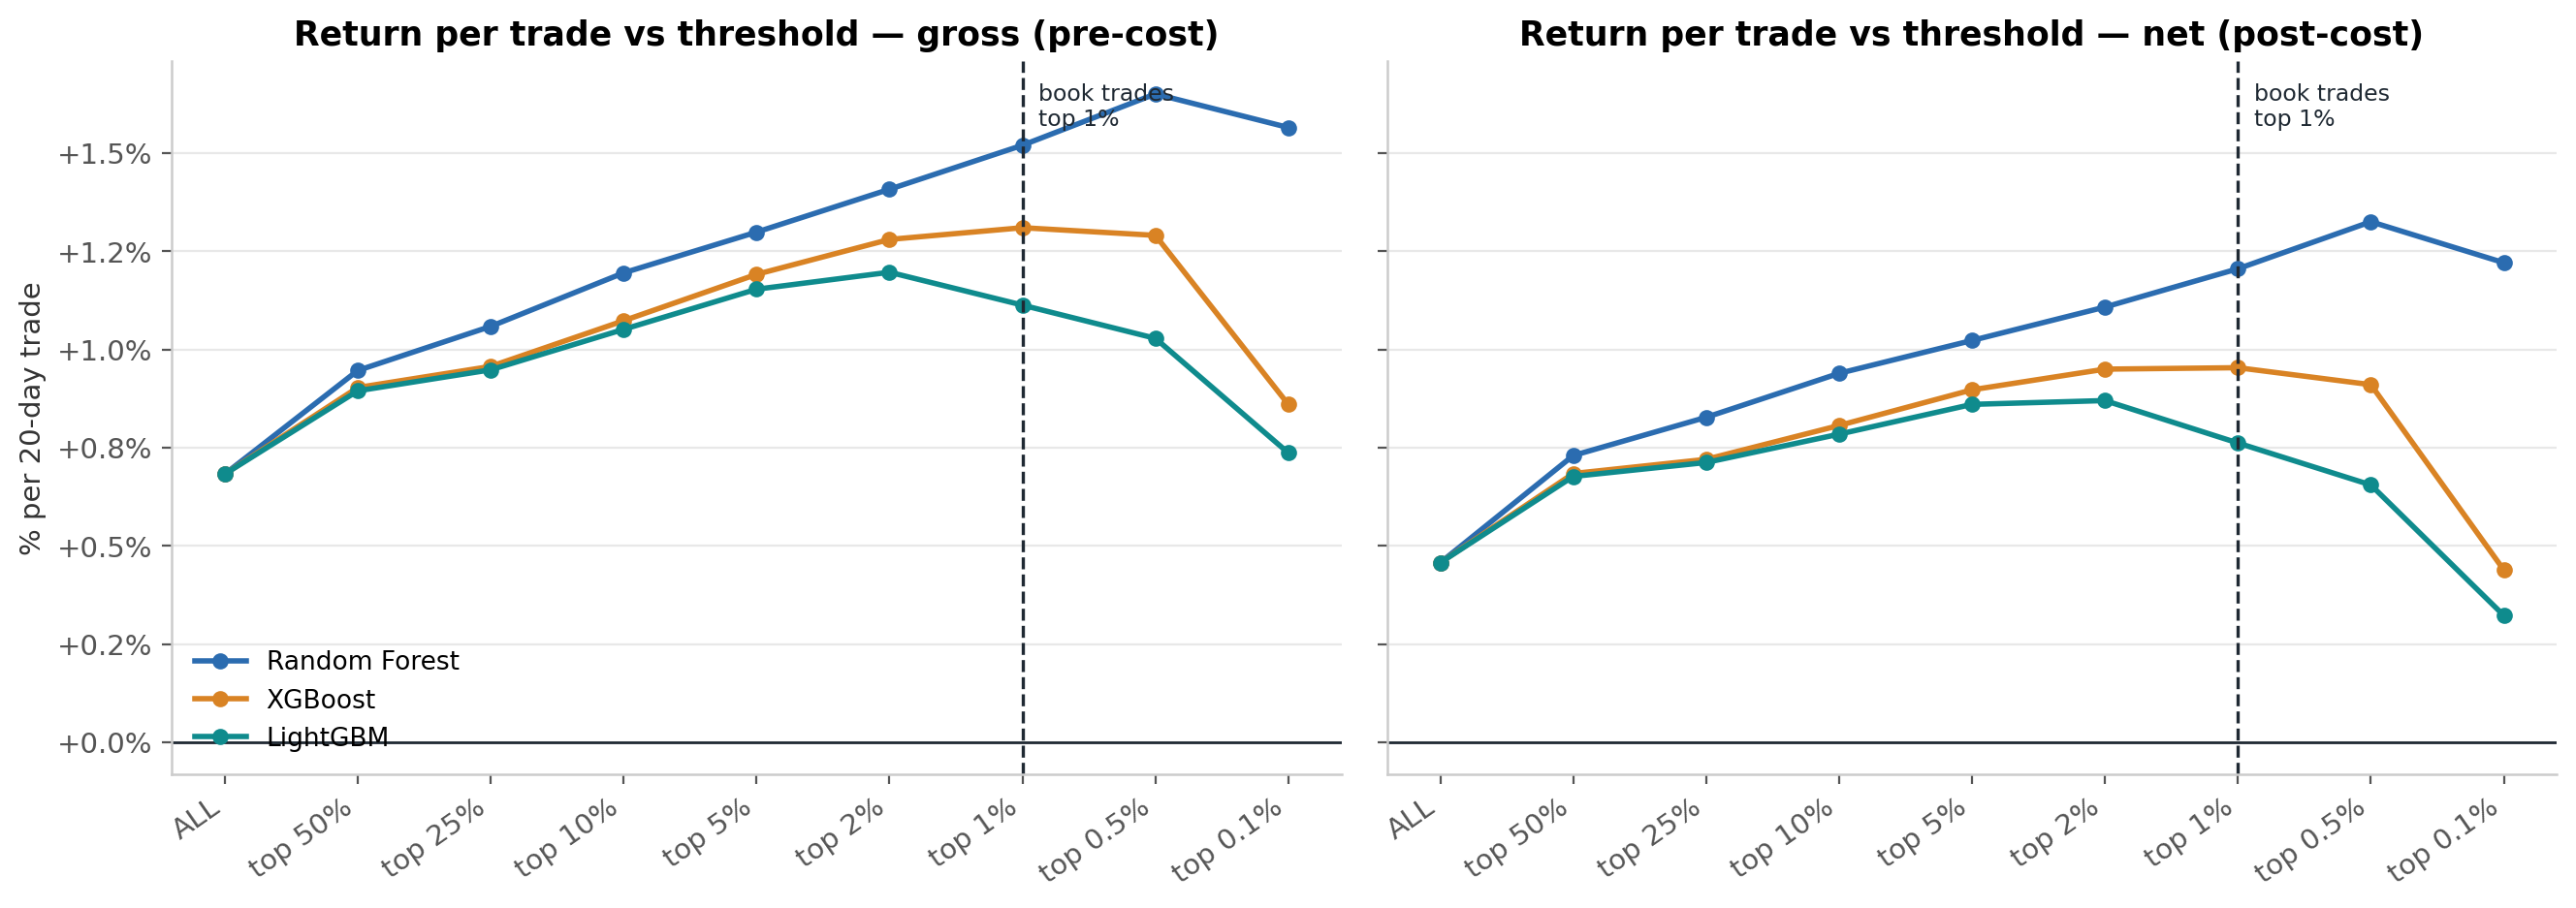


full figure inventory:
  holdout_01_equity.png
  holdout_02_dev_vs_holdout.png
  mc_01_dashboard.png
  mc_02_ruin_block_vs_iid.png
  mc_03_maxdd_distribution.png
  mc_04_drawdown_profile.png
  mc_05_equity_fans.png
  mc_06_sharpe_funnel.png
  mc_07_compounding_vs_static.png
  models_01_rank_ic.png
  models_02_decile_ladder.png
  models_03_threshold_sweep.png
  models_04_tail_behaviour.png
  results_01_walkforward_folds.png
  results_02_rank_ic.png
  results_03_decile_threshold.png
  results_04_final_fold.png
  results_05_calibration.png
  results_06_equity_curves.png
  results_07_alpha_beta.png
  results_08_top1_vs_top05.png
  results_09_bootstrap_ci.png
  results_10_random_null.png
  results_12_selection_bar.png


In [3]:
EXTRA = [
    ("holdout_01_equity",
     "**Holdout equity, H=40 top 1%.** The pure long book finished 3.02x against SPY's 2.06x, with "
     "excess Sharpe 1.16 against 1.15 — a dead heat risk-adjusted, a clear win on total return."),
    ("results_03_decile_threshold",
     "**Development: the signal works.** Monotone decile ladder from −0.60% to +2.35% per trade, and "
     "return per trade still rising at the top 1% where the book trades."),
    ("models_03_threshold_sweep",
     "**Why Random Forest.** Both boosters roll over in the tail; RF keeps climbing as the "
     "threshold tightens, which is the only part of the ranking the book trades."),
]
for name, caption in EXTRA:
    display(Markdown(caption))
    display(Image(filename=os.path.join(FIGDIR, f"{name}.png"), width=980))

print("\nfull figure inventory:")
for f in sorted(os.listdir(FIGDIR)):
    print(f"  {f}")

---
## The threshold decision, stated honestly

The report's decision order is: pick the model → pick the threshold → pick the entry schedule → Monte
Carlo → holdout. That order has one structural problem worth naming, because it is what produced the
under-filled book.

**The threshold and the entry schedule are not independent decisions.** The threshold sets how many
candidates exist per day (~11 at top 1%, ~6 at top 0.5%). The entry schedule sets how many you need on
a given day (`monthly_tranche2` wants 15). Fill is the interaction of the two. Choosing the threshold
*before* the schedule is exactly how you end up holding 11 names in a book designed for 30.

### What the evidence actually supports

| period | top 0.5% | top 1% | verdict |
|---|---|---|---|
| net per trade, DEV | **+1.33%** | +1.21% | 0.5% better by ~10% |
| net per trade, holdout | **+2.89%** | +2.68% | 0.5% better by ~8% |
| Sharpe, DEV (pure long) | **0.48** | 0.44 | 0.5% better by 0.04 |
| Sharpe, holdout (pure long) | 0.81 | **1.09** | 1% better by 0.28 |
| avg names held | 11 | 21 | 1% roughly doubles diversification |

**At the signal level, top 0.5% wins in both periods.** That part is consistent and is not luck — its
trades really are about 10% better each.

**At the portfolio level, neither period can distinguish them.** The DEV Sharpe advantage of 0.04 sits
inside a bootstrap 90% interval roughly ±0.36 wide. The holdout gap of 0.28 sits inside a standard
error of roughly ±0.65 for a 3.6-year window. Both differences are noise.

### So the deciding argument is not performance at all

It is diversification, and that part is arithmetic rather than statistical. Equal-weighted
idiosyncratic variance scales as 1/N. Going from ~21 names to ~11 nearly **doubles** the
diversifiable risk you are carrying. To be compensated for that you would need materially better
per-trade returns than the ~10% edge top 0.5% actually delivers.

That is why top 1% was the recommendation, and it is not a conclusion drawn from the holdout — it was
the stated reason before the holdout ran.

### The better answer is neither

Both thresholds are workarounds for the same defect: an entry schedule that demands more names on one
day than the signal produces. Splitting into more, smaller tranches (`tranches=4`, roughly weekly)
would draw top-0.5% names across four entry days and could fill 30 names at the tighter threshold —
capturing the better per-trade return *and* the diversification. That configuration has not been
tested and is the highest-value open item in the project.


---
## The argument in seven sentences

1. A random forest on 33 cross-sectionally ranked features predicts forward returns with a rank-IC of
   **+0.049** (t = 6.6 after correcting for overlapping holds), and its selection beats random draws
   from the same universe by 21 standard deviations with 0 of 2,000 random draws matching it.
2. Random Forest beats XGBoost and LightGBM, and the margin is concentrated exactly where it matters —
   both boosters lose their ranking ability in the extreme tail the book trades.
3. Three execution choices were settled by experiment, not assumption: a ~42-session hold beats ~21
   (§11), a **40-day label matched to that hold** beats a 20-day one (§13), and **top 1%** beats top
   0.5% because the tighter cut leaves the book holding 11 names instead of 20 (§9).
4. On that configuration the 80/20 hedge returns **+13.9%** a year at **Sharpe 0.52** against SPY's
   **0.34**, with a shallower drawdown (−50.3% vs −55.2%) and better Calmar (0.28 vs 0.16).
5. Monte Carlo puts its three-year ruin risk at **1.1%** — the same as SPY's 1.0% — for a median return
   of **+48.5%** against SPY's **+31.9%**, with a better downside tail on CVaR, 5th-percentile wealth
   and probability of loss.
6. The remaining defect is mechanical rather than statistical: the book fills only ~20 of its 30-name
   target, because the monthly schedule needs 15 candidates on one day and ~11 exist.
7. In the untouched 2023-2026 holdout — run on the earlier H=20 configuration — the **signal held**
   (rank-IC +0.034, net return per trade roughly doubled) but **no book beat SPY risk-adjusted**, with
   the short leg turning into a straight drag in a sustained bull market.

## Open items

- **The fill defect.** `tranches=4` (weekly entry) would let the book hold 30 names, and at the tighter
  threshold. Untested, and the highest-value change available.
- **H=40 is unvalidated out of sample.** It came from a question raised after the holdout ran. Strong
  DEV evidence and a clear mechanism, but the holdout tests H=20. Re-running the holdout on H=40 would
  not be an out-of-sample test.
- **The hedge is regime-conditional.** Strong evidence for it in 2008 and 2022, strong evidence against
  it in 2023-2026. A fixed weight is the wrong answer to that.
- **Alpha is not statistically significant** (t of 1.60 and 1.74 against a bar of 2), even though the
  point estimates are ~+6-7%/yr and the ranking is informative.
- **No second holdout exists.** Anything further tested on 2023-2026 is development data now.
